## Credit Card

In [1]:
## Dataclensing

import pandas as pd

df = pd.read_csv("credit_card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
## check for missing values
df.isna().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [5]:
##check outliers
for col in df.columns:
    print(f"Column: {col}")
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    fence_high = q3 + 1.5 * iqr
    fence_low = q1 - 1.5 * iqr
    outliers = df[(df[col] < fence_low) | (df[col] > fence_high)]
    print(outliers.shape)

Column: ID
(0, 25)
Column: LIMIT_BAL
(167, 25)
Column: SEX
(0, 25)
Column: EDUCATION
(454, 25)
Column: MARRIAGE
(0, 25)
Column: AGE
(272, 25)
Column: PAY_0
(3130, 25)
Column: PAY_2
(4410, 25)
Column: PAY_3
(4209, 25)
Column: PAY_4
(3508, 25)
Column: PAY_5
(2968, 25)
Column: PAY_6
(3079, 25)
Column: BILL_AMT1
(2400, 25)
Column: BILL_AMT2
(2395, 25)
Column: BILL_AMT3
(2469, 25)
Column: BILL_AMT4
(2622, 25)
Column: BILL_AMT5
(2725, 25)
Column: BILL_AMT6
(2693, 25)
Column: PAY_AMT1
(2745, 25)
Column: PAY_AMT2
(2714, 25)
Column: PAY_AMT3
(2598, 25)
Column: PAY_AMT4
(2994, 25)
Column: PAY_AMT5
(2945, 25)
Column: PAY_AMT6
(2958, 25)
Column: default.payment.next.month
(6636, 25)


In [7]:
for col in df.columns[:-1]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    fence_high = q3 + 1.5 * iqr
    fence_low = q1 - 1.5 * iqr
    outliers = df[(df[col] < fence_low) | (df[col] > fence_high)]
    df = df[(df[col] >= fence_low) & (df[col] <= fence_high)]

In [9]:
df["default.payment.next.month"].value_counts()

default.payment.next.month
0    7115
1    1509
Name: count, dtype: int64

In [10]:
## check for duplicates
df.duplicated().sum()

0

In [11]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
18,19,360000.0,2,1,1,49,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19,20,180000.0,2,1,2,29,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8624 entries, 3 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          8624 non-null   int64  
 1   LIMIT_BAL                   8624 non-null   float64
 2   SEX                         8624 non-null   int64  
 3   EDUCATION                   8624 non-null   int64  
 4   MARRIAGE                    8624 non-null   int64  
 5   AGE                         8624 non-null   int64  
 6   PAY_0                       8624 non-null   int64  
 7   PAY_2                       8624 non-null   int64  
 8   PAY_3                       8624 non-null   int64  
 9   PAY_4                       8624 non-null   int64  
 10  PAY_5                       8624 non-null   int64  
 11  PAY_6                       8624 non-null   int64  
 12  BILL_AMT1                   8624 non-null   float64
 13  BILL_AMT2                   8624 non-

In [13]:
## univariate analysis
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,...,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000,8624.000000
mean,14716.334763,138438.079777,1.605288,1.831517,1.555427,35.170571,-0.356563,-0.686109,-0.744202,-0.779337,...,12527.205009,10757.737361,9908.732723,1491.433094,1335.212083,1006.924745,808.040005,801.734926,753.555195,0.174977
std,8738.450077,112368.913376,0.488817,0.698086,0.525529,9.141967,0.867853,0.824456,0.849290,0.867753,...,16241.967381,14182.749742,13666.149415,1361.189165,1221.845625,1021.898382,887.231339,887.832377,871.631579,0.379969
min,4.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-7905.000000,-10213.000000,-11610.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7170.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000,209.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,14478.500000,100000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,2827.500000,1885.500000,1280.000000,1440.000000,1300.000000,930.500000,600.000000,569.500000,489.500000,0.000000
75%,22270.000000,200000.000000,2.000000,2.000000,2.000000,42.000000,0.000000,0.000000,0.000000,0.000000,...,21000.500000,19317.000000,18715.500000,2005.000000,2000.000000,1576.000000,1208.000000,1254.250000,1180.000000,0.000000
max,30000.000000,510000.000000,2.000000,3.000000,3.000000,60.000000,1.000000,1.000000,0.000000,0.000000,...,74100.000000,59984.000000,49701.000000,7620.000000,6284.000000,5000.000000,4186.000000,4000.000000,3746.000000,1.000000


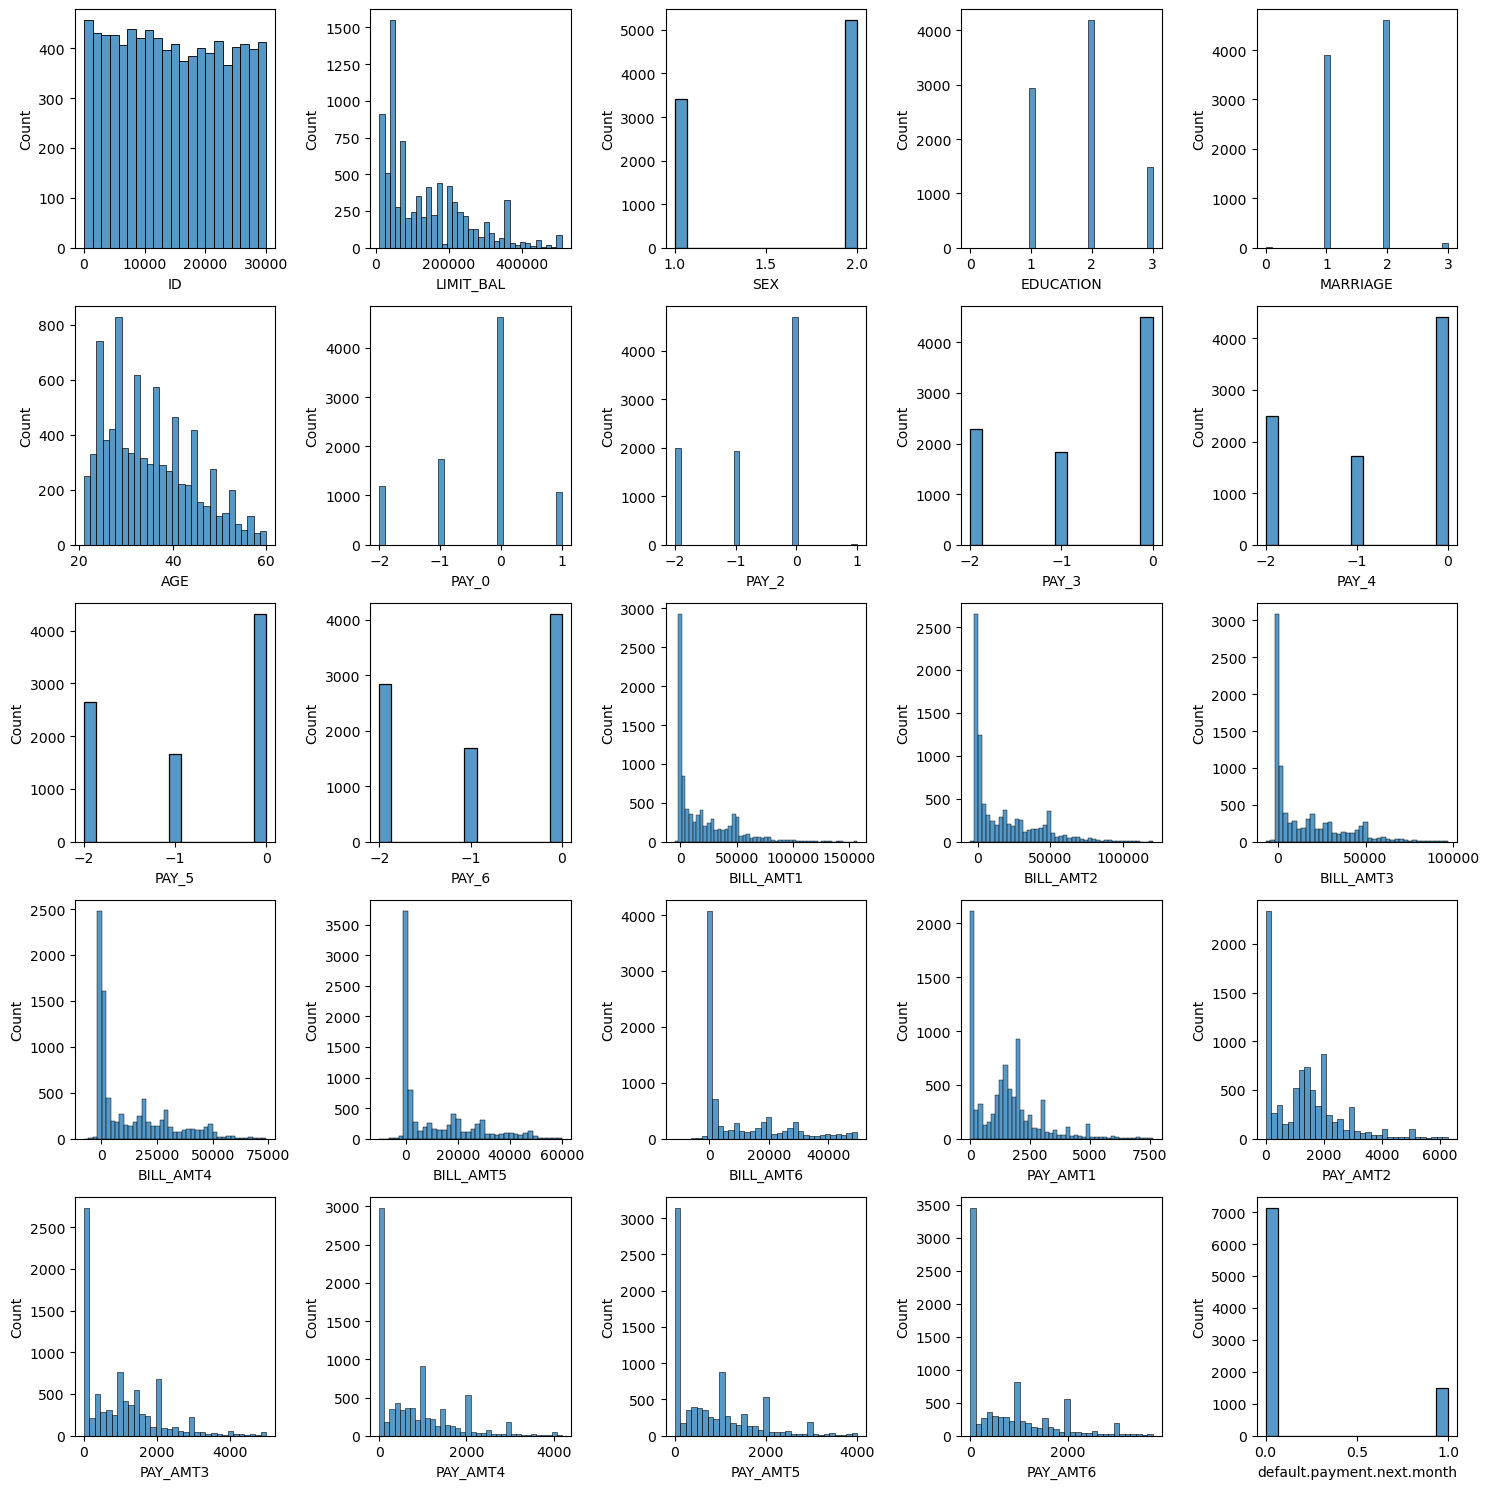

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 15))

for i in range(len(df.columns)):
    plt.subplot(5,5, i+1)
    sns.histplot(x = df.columns[i], data=df)
    plt.tight_layout()

In [ ]:
## multivariate analysis
sns.pairplot(df)

In [22]:
filtered_cols = ['BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
len(filtered_cols)

6

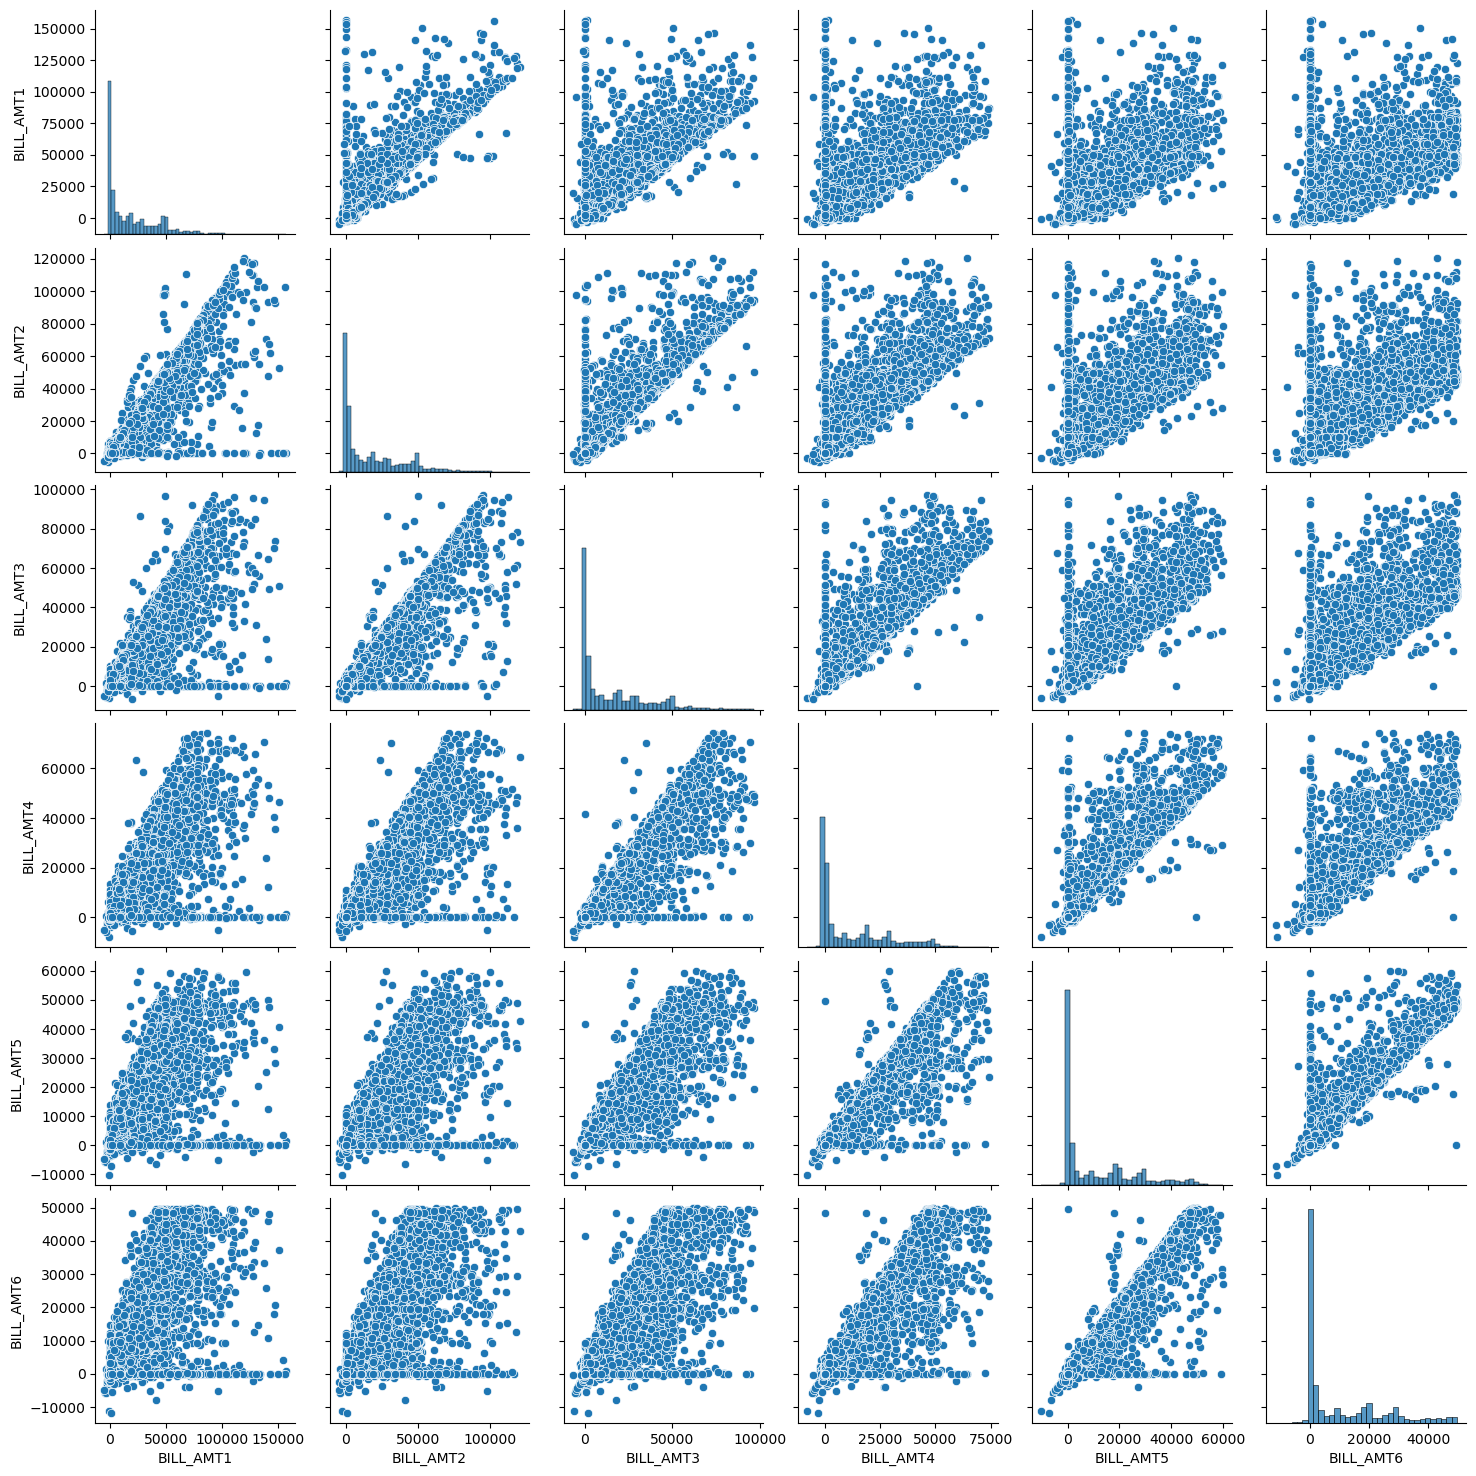

In [23]:
sns.pairplot(df[filtered_cols])

<Axes: >

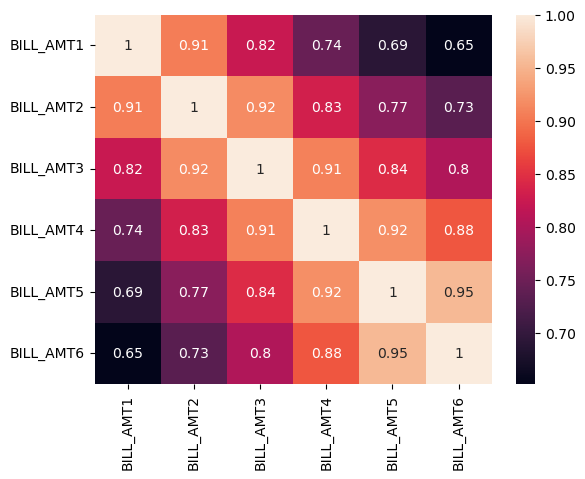

In [24]:
sns.heatmap(df[filtered_cols].corr(), annot=True)

In [25]:
##feature engineering
df["bill_amt_1_2_diff"] = df["BILL_AMT2"] - df["BILL_AMT1"]
df["bill_amt_2_3_diff"] = df["BILL_AMT3"] - df["BILL_AMT2"]
df["bill_amt_3_4_diff"] = df["BILL_AMT4"] - df["BILL_AMT3"]
df["bill_amt_4_5_diff"] = df["BILL_AMT5"] - df["BILL_AMT4"]
df["bill_amt_5_6_diff"] = df["BILL_AMT6"] - df["BILL_AMT5"]

In [26]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,bill_amt_1_2_diff,bill_amt_2_3_diff,bill_amt_3_4_diff,bill_amt_4_5_diff,bill_amt_5_6_diff
3,4,50000.0,2,2,1,37,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,1243.0,1058.0,-20977.0,645.0,588.0
5,6,50000.0,1,1,2,37,0,0,0,0,...,657.0,1000.0,1000.0,800.0,0,-7331.0,539.0,-38214.0,225.0,405.0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,0.0,581.0,1687.0,1542.0,0,-11496.0,221.0,-380.0,-380.0,726.0
18,19,360000.0,2,1,1,49,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0
19,20,180000.0,2,1,2,29,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8624 entries, 3 to 29999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          8624 non-null   int64  
 1   LIMIT_BAL                   8624 non-null   float64
 2   SEX                         8624 non-null   int64  
 3   EDUCATION                   8624 non-null   int64  
 4   MARRIAGE                    8624 non-null   int64  
 5   AGE                         8624 non-null   int64  
 6   PAY_0                       8624 non-null   int64  
 7   PAY_2                       8624 non-null   int64  
 8   PAY_3                       8624 non-null   int64  
 9   PAY_4                       8624 non-null   int64  
 10  PAY_5                       8624 non-null   int64  
 11  PAY_6                       8624 non-null   int64  
 12  BILL_AMT1                   8624 non-null   float64
 13  BILL_AMT2                   8624 non-

In [28]:
## train test split

x = df.drop(columns=["default.payment.next.month"])
y = df["default.payment.next.month"]

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

In [30]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6036, 29)
(2588, 29)
(6036,)
(2588,)


In [31]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(x_train, y_train)

DecisionTreeClassifier()

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [33]:
## hyperparameter tuning
params = {
    "max_depth": [2, 3, 5, 10, 15],
    "min_samples_leaf": [10, 50, 100, 200, 300],
}

In [34]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=params, cv=5, scoring="roc_auc")
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 3, 5, 10, 15],
                         'min_samples_leaf': [10, 50, 100, 200, 300]},
             scoring='roc_auc')

In [35]:
rf_base = grid_search.best_estimator_
rf_base.fit(x_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=50)

In [41]:
## evaluate the model
from sklearn.metrics import recall_score

y_dtree = dtree.predict(x_test)
y_rf = rf.predict(x_test)
y_rf_base = rf_base.predict(x_test)

In [43]:
# Calculate recall scores
print(recall_score(y_test, y_dtree, pos_label=1, average="binary"))
print(recall_score(y_test, y_rf, pos_label=1, average="binary"))
print(recall_score(y_test, y_rf_base, pos_label=1, average="binary"))

0.23841059602649006
0.06181015452538632
0.0


In [44]:
from sklearn.metrics import precision_score

# Calculate precision scores
print(precision_score(y_test, y_dtree, pos_label=1, average="binary"))
print(precision_score(y_test, y_rf, pos_label=1, average="binary"))
print(precision_score(y_test, y_rf_base, pos_label=1, average="binary"))

0.2151394422310757
0.3835616438356164
0.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
from sklearn.metrics import roc_auc_score

# Calculate ROC AUC scores
y_dtree_proba = dtree.predict_proba(x_test)[:, 1]
y_rf_proba = rf.predict_proba(x_test)[:, 1]
y_rf_base_proba = rf_base.predict_proba(x_test)[:, 1]

print(roc_auc_score(y_test, y_dtree_proba))
print(roc_auc_score(y_test, y_rf_proba))
print(roc_auc_score(y_test, y_rf_base_proba))


0.5269336352497789
0.6060140308430397
0.6440782501253677


In [46]:
import pandas as pd

df = pd.read_csv("sallary_estimation.csv")

df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [47]:
df["status"].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [48]:
df = df[df["status"] == "Placed"]

In [49]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
7,8,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 213
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           148 non-null    int64  
 1   gender          148 non-null    object 
 2   ssc_p           148 non-null    float64
 3   ssc_b           148 non-null    object 
 4   hsc_p           148 non-null    float64
 5   hsc_b           148 non-null    object 
 6   hsc_s           148 non-null    object 
 7   degree_p        148 non-null    float64
 8   degree_t        148 non-null    object 
 9   workex          148 non-null    object 
 10  etest_p         148 non-null    float64
 11  specialisation  148 non-null    object 
 12  mba_p           148 non-null    float64
 13  status          148 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 18.5+ KB


In [51]:
## check missing values

df.isna().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [53]:
##chec outliers
df_num = df.select_dtypes(["int64", "float64"])
col_num = df_num.columns
col_num

Index(['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary'], dtype='object')

In [54]:
for col in col_num:
    print(f"Column: {col}")
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    fence_high = q3 + 1.5 * iqr
    fence_low = q1 - 1.5 * iqr
    outliers = df[(df[col] < fence_low) | (df[col] > fence_high)]
    print(outliers.shape)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    fence_high = q3 + 1.5 * iqr
    fence_low = q1 - 1.5 * iqr
    outliers = df[(df[col] < fence_low) | (df[col] > fence_high)]
    print(outliers.shape)

Column: sl_no
(0, 15)
(0, 15)
Column: ssc_p
(0, 15)
(0, 15)
Column: hsc_p
(2, 15)
(2, 15)
Column: degree_p
(3, 15)
(3, 15)
Column: etest_p
(0, 15)
(0, 15)
Column: mba_p
(0, 15)
(0, 15)
Column: salary
(15, 15)
(15, 15)


In [55]:
##check duplicated values
df.duplicated().sum()

0

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 213
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           148 non-null    int64  
 1   gender          148 non-null    object 
 2   ssc_p           148 non-null    float64
 3   ssc_b           148 non-null    object 
 4   hsc_p           148 non-null    float64
 5   hsc_b           148 non-null    object 
 6   hsc_s           148 non-null    object 
 7   degree_p        148 non-null    float64
 8   degree_t        148 non-null    object 
 9   workex          148 non-null    object 
 10  etest_p         148 non-null    float64
 11  specialisation  148 non-null    object 
 12  mba_p           148 non-null    float64
 13  status          148 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 18.5+ KB


In [57]:
## univariate analysis

df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,106.878378,71.721486,69.926554,68.740541,73.238041,62.579392,288655.405405
std,60.682502,8.715445,9.329268,6.518087,13.729333,5.884583,93457.452420
min,1.000000,49.000000,50.830000,56.000000,50.000000,52.380000,200000.000000
25%,57.750000,65.000000,63.000000,65.000000,60.000000,57.772500,240000.000000
50%,108.500000,72.500000,68.000000,68.000000,72.000000,62.245000,265000.000000
75%,153.250000,78.125000,75.250000,72.422500,85.000000,66.760000,300000.000000
max,214.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [58]:
col_num

Index(['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary'], dtype='object')

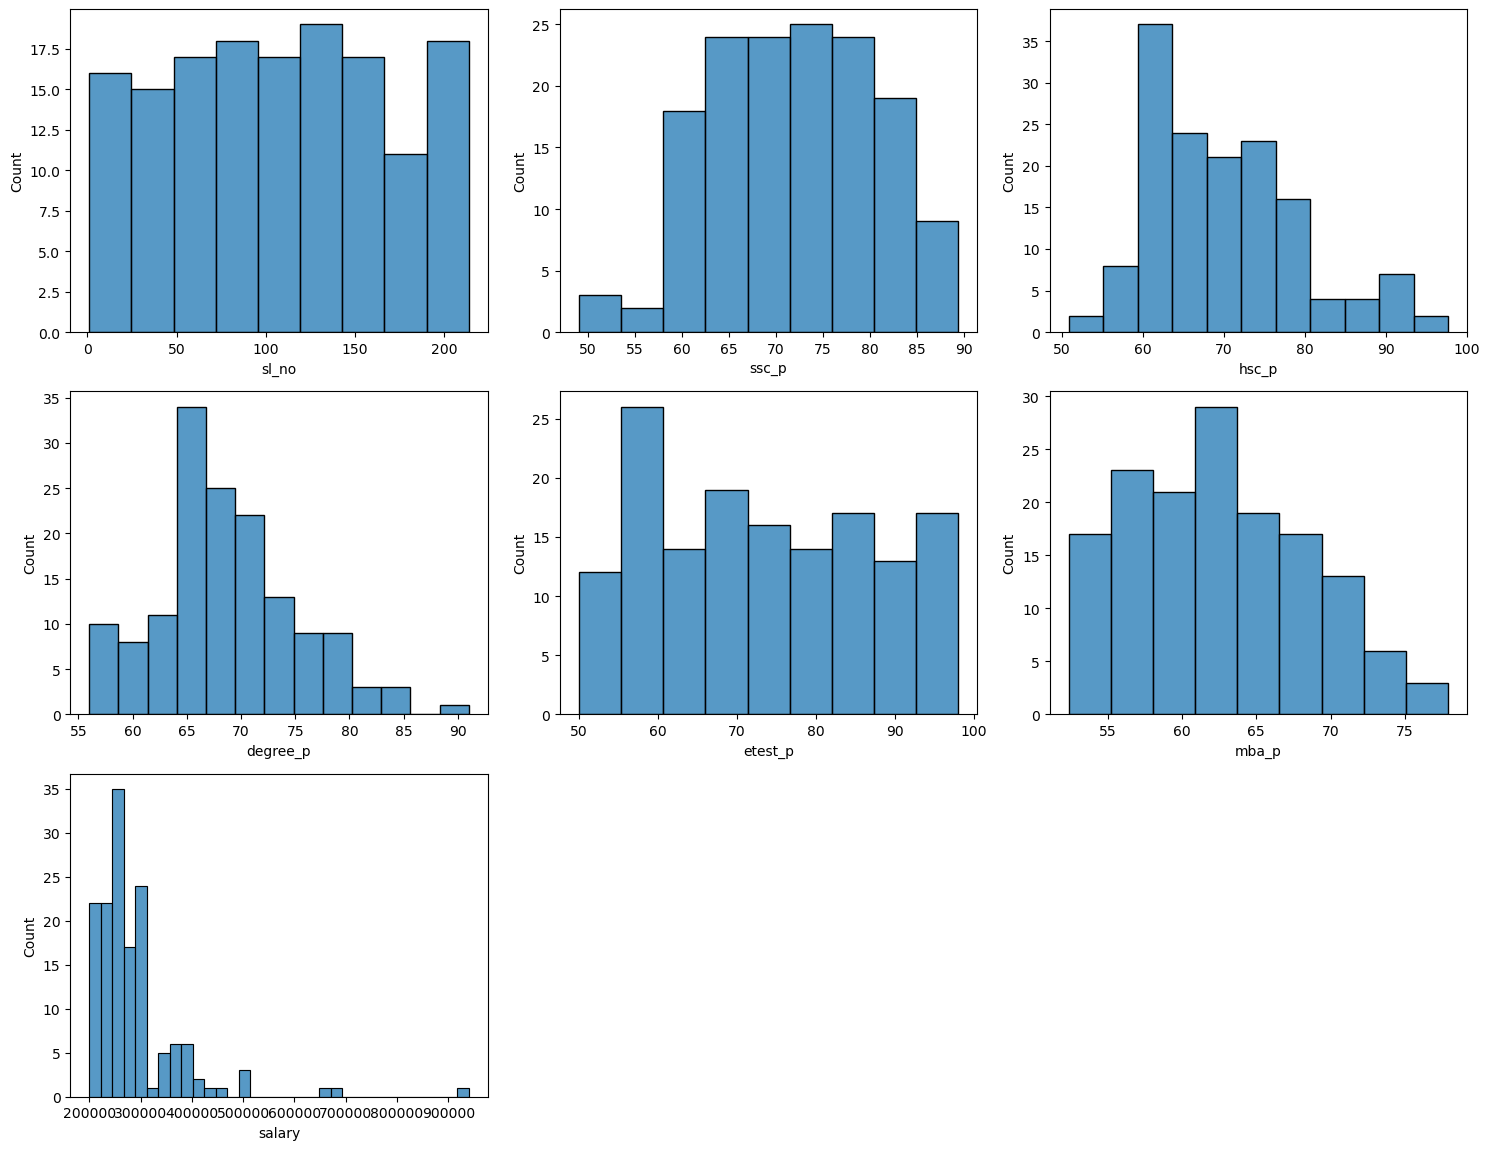

In [62]:
plt.figure(figsize=(15, 15))
for i in range(len(col_num)):
    plt.subplot(4, 3, i+1)
    sns.histplot(x= col_num[i], data= df)
    plt.tight_layout()

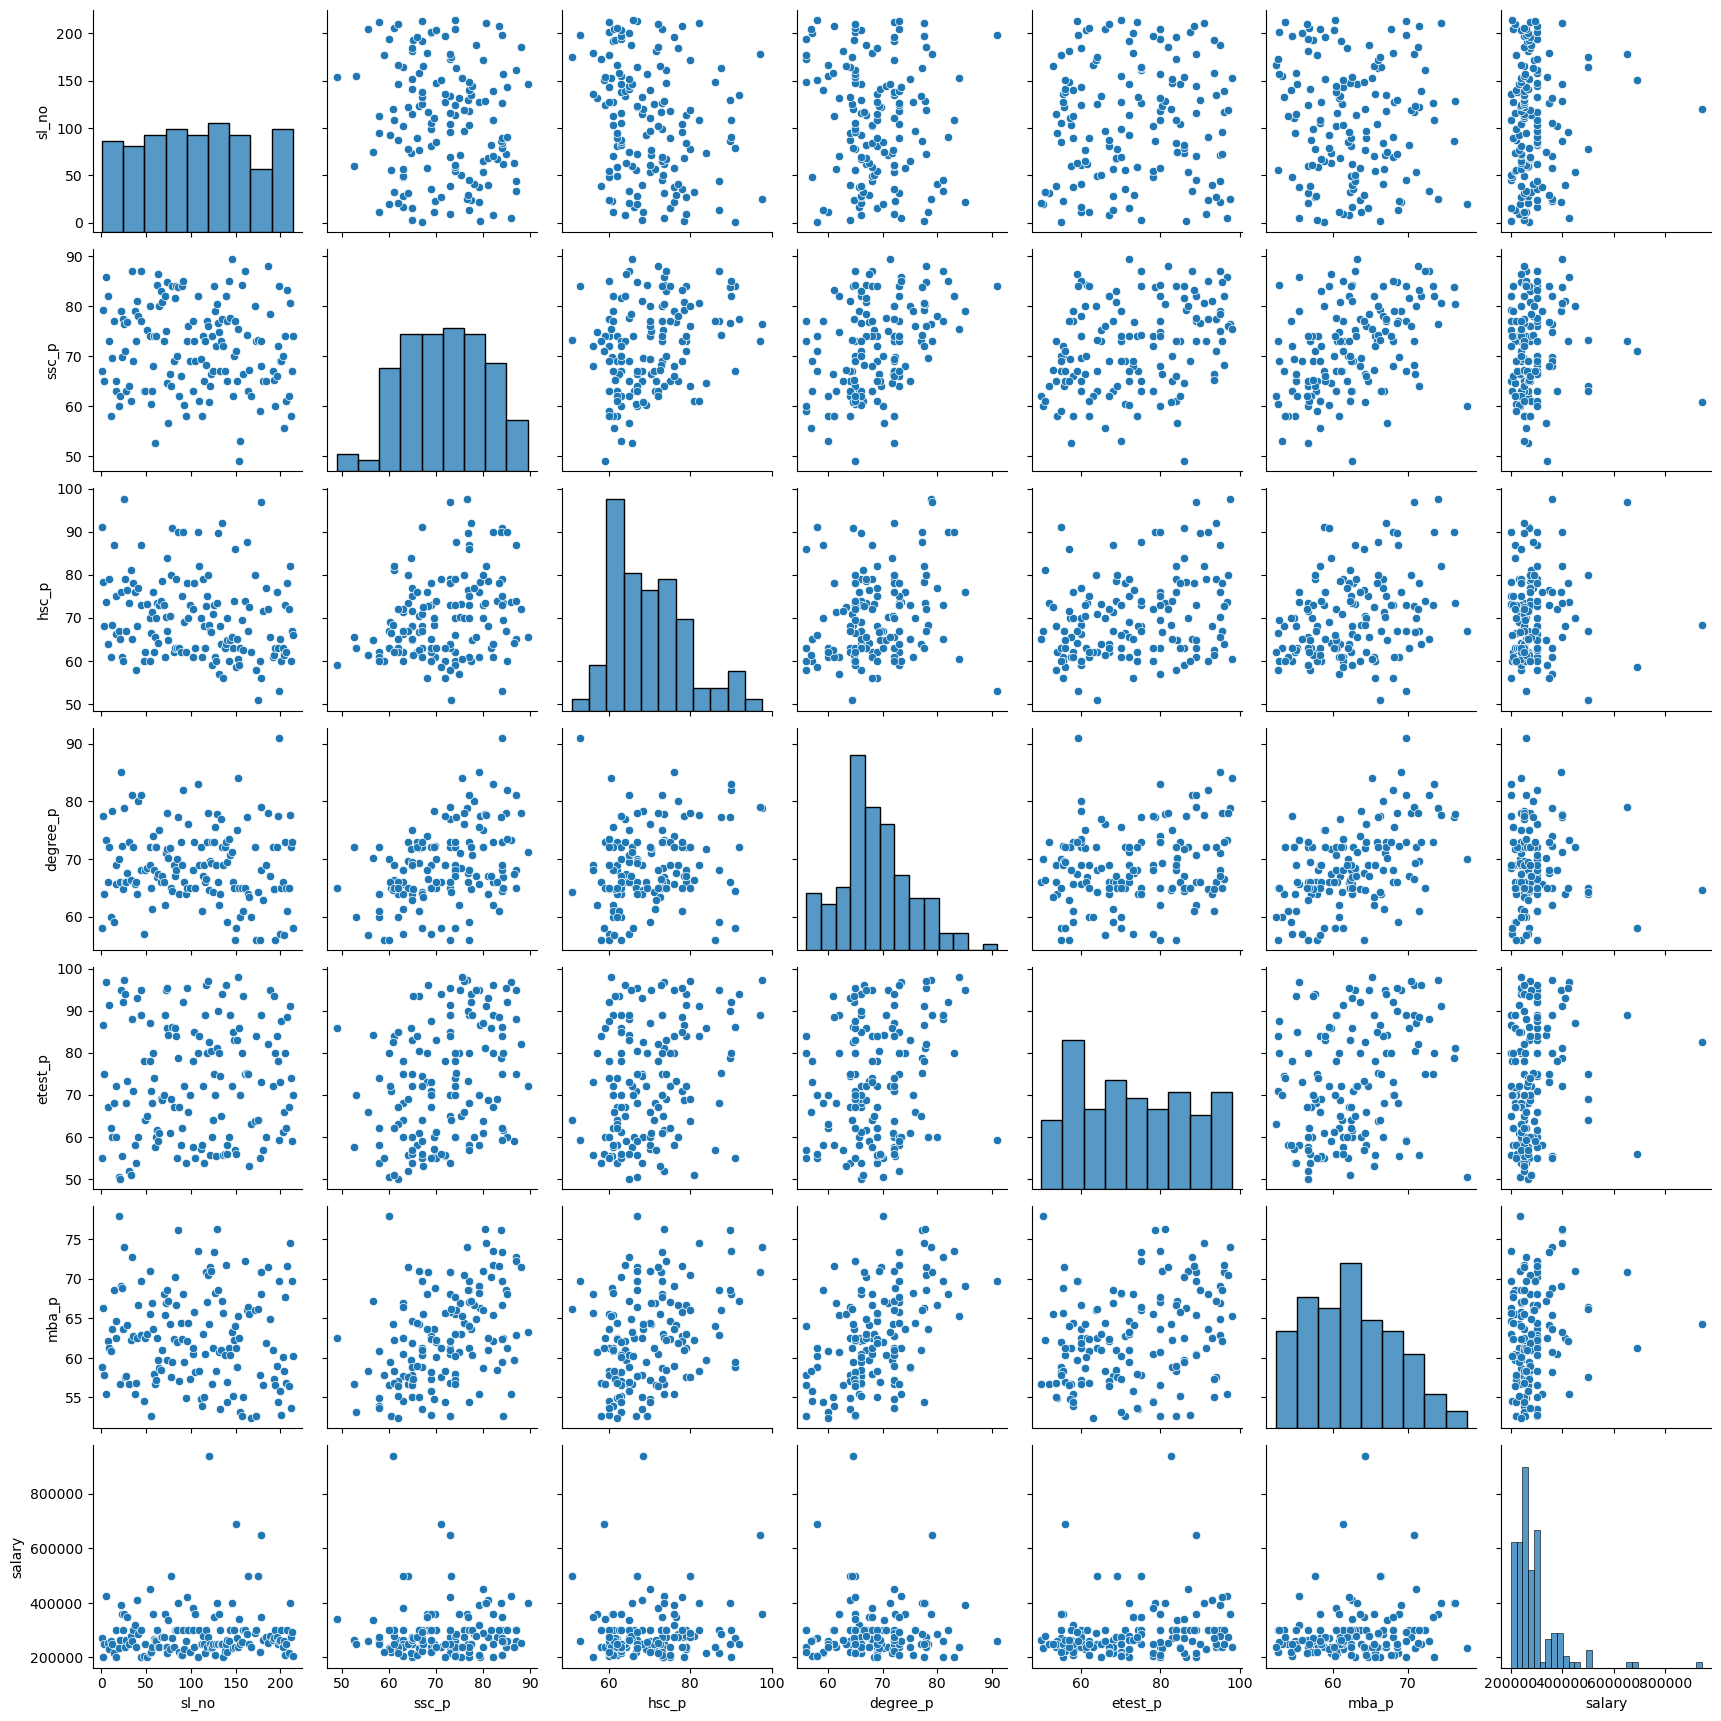

In [63]:
##multivariate analysis
sns.pairplot(df[col_num])

<Axes: >

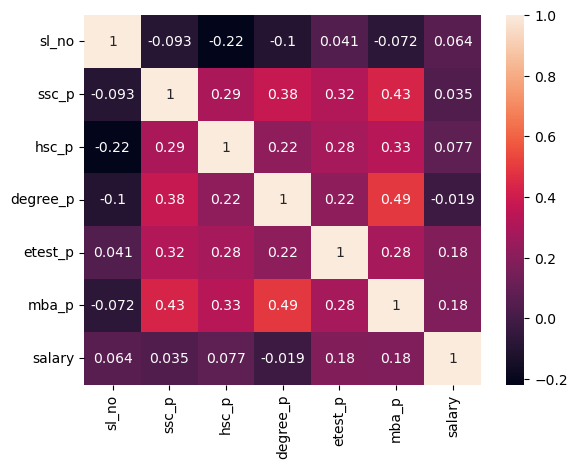

In [64]:
sns.heatmap(df[col_num].corr(), annot=True)

In [65]:
## additional data preparation before modeling

##feature engineering

df["ssc_to_hsc_p"] = df["hsc_p"] / df["ssc_p"]
df["hsc_to_degree_p"] = df["degree_p"] / df["hsc_p"]
df["degree_to_mba_p"] = df["mba_p"] / df["degree_p"]

In [66]:
df

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,ssc_to_hsc_p,hsc_to_degree_p,degree_to_mba_p
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0,1.358209,0.637363,1.013793
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0,0.987394,0.989148,0.855447
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0,1.046154,0.941176,0.903125
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0,0.857809,0.995924,0.757162
7,8,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0,0.780488,1.031250,0.941515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,210,M,62.00,Central,72.00,Central,Commerce,65.00,Comm&Mgmt,No,67.0,Mkt&Fin,56.49,Placed,216000.0,1.161290,0.902778,0.869077
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0,1.017370,0.946341,0.959923
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0,1.034483,1.200000,0.744722
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0,1.000000,1.089552,0.955068


In [67]:
## one hot encoding
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 213
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sl_no            148 non-null    int64  
 1   gender           148 non-null    object 
 2   ssc_p            148 non-null    float64
 3   ssc_b            148 non-null    object 
 4   hsc_p            148 non-null    float64
 5   hsc_b            148 non-null    object 
 6   hsc_s            148 non-null    object 
 7   degree_p         148 non-null    float64
 8   degree_t         148 non-null    object 
 9   workex           148 non-null    object 
 10  etest_p          148 non-null    float64
 11  specialisation   148 non-null    object 
 12  mba_p            148 non-null    float64
 13  status           148 non-null    object 
 14  salary           148 non-null    float64
 15  ssc_to_hsc_p     148 non-null    float64
 16  hsc_to_degree_p  148 non-null    float64
 17  degree_to_mba_p  148 

In [68]:
df = df.drop(columns=["sl_no"])
df

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,ssc_to_hsc_p,hsc_to_degree_p,degree_to_mba_p
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0,1.358209,0.637363,1.013793
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0,0.987394,0.989148,0.855447
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0,1.046154,0.941176,0.903125
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0,0.857809,0.995924,0.757162
7,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0,0.780488,1.031250,0.941515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,M,62.00,Central,72.00,Central,Commerce,65.00,Comm&Mgmt,No,67.0,Mkt&Fin,56.49,Placed,216000.0,1.161290,0.902778,0.869077
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0,1.017370,0.946341,0.959923
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0,1.034483,1.200000,0.744722
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0,1.000000,1.089552,0.955068


In [71]:
df = pd.get_dummies(df)

df

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,ssc_to_hsc_p,hsc_to_degree_p,degree_to_mba_p,gender_F,...,hsc_s_Commerce,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,workex_No,workex_Yes,specialisation_Mkt&Fin,specialisation_Mkt&HR,status_Placed
0,67.00,91.00,58.00,55.0,58.80,270000.0,1.358209,0.637363,1.013793,False,...,True,False,False,False,True,True,False,False,True,True
1,79.33,78.33,77.48,86.5,66.28,200000.0,0.987394,0.989148,0.855447,False,...,False,True,False,False,True,False,True,True,False,True
2,65.00,68.00,64.00,75.0,57.80,250000.0,1.046154,0.941176,0.903125,False,...,False,False,True,False,False,True,False,True,False,True
4,85.80,73.60,73.30,96.8,55.50,425000.0,0.857809,0.995924,0.757162,False,...,True,False,True,False,False,True,False,True,False,True
7,82.00,64.00,66.00,67.0,62.14,252000.0,0.780488,1.031250,0.941515,False,...,False,True,False,False,True,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,62.00,72.00,65.00,67.0,56.49,216000.0,1.161290,0.902778,0.869077,False,...,True,False,True,False,False,True,False,True,False,True
210,80.60,82.00,77.60,91.0,74.49,400000.0,1.017370,0.946341,0.959923,False,...,True,False,True,False,False,True,False,True,False,True
211,58.00,60.00,72.00,74.0,53.62,275000.0,1.034483,1.200000,0.744722,False,...,False,True,False,False,True,True,False,True,False,True
212,67.00,67.00,73.00,59.0,69.72,295000.0,1.000000,1.089552,0.955068,False,...,True,False,True,False,False,False,True,True,False,True


In [73]:
## train test split
x = df.drop(columns=["salary"])
y = df["salary"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [74]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(118, 25)
(30, 25)
(118,)
(30,)


In [75]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [76]:
## evaluate the model

from sklearn.metrics import mean_absolute_error

y_lr = lr.predict(x_test)

mean_absolute_error(y_test, y_lr)


71386.0201114904

In [77]:
import numpy as np 

print(np.mean(y_test))
print(np.std(y_test))

292266.6666666667
77906.7533800647


In [78]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_test, y_lr)

83846.43567677499

In [79]:
from sklearn.metrics import r2_score

r2_score(y_test, y_lr)

-0.15829451083156676

In [80]:
y_lr

array([282612.5737008 , 261351.75792851, 296479.80035096, 251538.35233134,
       340426.00091243, 221537.38634981, 189171.75651528, 293368.39500518,
       202995.50337831, 312955.37899522, 316812.1091017 , 349016.47283104,
       355859.45057844, 268535.1973425 , 306332.99352571, 308871.23596519,
       281086.2997886 , 308182.27621871, 335999.02092243, 212681.38400116,
       300235.00399608, 281179.8849337 , 301766.33068085, 278972.50954578,
       332350.08955624, 306121.43780596, 358654.52926612, 328191.74491604,
       305517.43994772, 379064.84569674])

In [85]:
diff = y_test - y_lr

predection_threshold = [x for x in diff if (x < 77906.7533800647) and (x > -77906.7533800647)]
len(predection_threshold)


15